# **Cardiovascular Disease Prediction- A Machine Learning Pipeline**

Created by [Gábor Dányi](https://www.linkedin.com/in/gabordanyi96/)
## Context
Cardiovascular disease (CVD), a collective term for disorders of the heart and blood vessels, represents a critical public health challenge. The insidious process of arterial narrowing, fueled by lipid deposition and subsequent plaque formation, compromises blood supply to essential organs. With CVDs responsible for a staggering proportion of global deaths, the imperative for timely diagnosis and effective preventative strategies cannot be overstated.

## Project outline

The primary objective of this project is to develop a robust machine learning model capable of accurately predicting individual risk for CVDs based on comprehensive health data.

1.  **Preprocessing and Validation Checks**

2.  **Exploratory Data Analysis and Visualization:**

3.  **Select and Train Model**

4.  **Model Performance Evaluation**

5.  **Hyperparameter Tuning with Bayesian Optimization (BO)**

6.  **Test Set**


## Data source

Data for this project originates from the '[Cardiovascular Disease dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)' available on Kaggle. This dataset provides a substantial sample (70,000 records) of patients between 30 and 70 years old. Each record includes 11 features relevant to CVD risk, such as age, gender, blood pressure, cholesterol levels, and smoking status. The primary objective is to predict the binary target variable indicating the presence or absence of CVD. All of the dataset values were collected at the moment of medical examination.



<table>
  <thead>
    <tr>
      <th>Feature</th>
      <th>Feature Type</th>
      <th>Column Name</th>
      <th>Data Type/Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Age</td>
      <td>Objective Feature</td>
      <td>age</td>
      <td>int (days)</td>
    </tr>
    <tr>
      <td>Height</td>
      <td>Objective Feature</td>
      <td>height</td>
      <td>int (cm)</td>
    </tr>
    <tr>
      <td>Weight</td>
      <td>Objective Feature</td>
      <td>weight</td>
      <td>float (kg)</td>
    </tr>
    <tr>
      <td>Gender</td>
      <td>Objective Feature</td>
      <td>gender</td>
      <td>categorical code</td>
    </tr>
    <tr>
      <td>Systolic blood pressure</td>
      <td>Examination Feature</td>
      <td>ap_hi</td>
      <td>int</td>
    </tr>
    <tr>
      <td>Diastolic blood pressure</td>
      <td>Examination Feature</td>
      <td>ap_lo</td>
      <td>int</td>
    </tr>
    <tr>
      <td>Cholesterol</td>
      <td>Examination Feature</td>
      <td>cholesterol</td>
      <td>1: normal, 2: above normal, 3: well above normal</td>
    </tr>
    <tr>
      <td>Glucose</td>
      <td>Examination Feature</td>
      <td>gluc</td>
      <td>1: normal, 2: above normal, 3: well above normal</td>
    </tr>
    <tr>
      <td>Smoking</td>
      <td>Subjective Feature</td>
      <td>smoke</td>
      <td>binary</td>
    </tr>
    <tr>
      <td>Alcohol intake</td>
      <td>Subjective Feature</td>
      <td>alco</td>
      <td>binary</td>
    </tr>
    <tr>
      <td>Physical activity</td>
      <td>Subjective Feature</td>
      <td>active</td>
      <td>binary</td>
    </tr>
    <tr>
      <td>Presence or absence of cardiovascular disease</td>
      <td>Target Variable</td>
      <td>cardio</td>
      <td>binary</td>
    </tr>
  </tbody>
</table>



In [ ]:
#@title Install dependencies
import kagglehub
import pandas as pd
import numpy as np
import random
import os

#For the ML pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, roc_auc_score, log_loss
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

#For hyperparameter optimization
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials, space_eval
!pip install scikit-optimize
from skopt import forest_minimize
from skopt.space import Real, Integer, Categorical
from skopt.plots import plot_convergence


#For plotting
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
#@title Import CVD dataset
try:
    path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
    print("Dataset downloaded to:", path)
except Exception as e:
    print(f"An error occurred during download: {e}")
    # Handle the error appropriately, e.g., exit if the download is critical

# Find the CSV file.  This is more robust than hardcoding the path.
def find_csv_file(base_path):
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.endswith(".csv"):
                return os.path.join(root, file)
    return None  # Return None if no CSV file is found.

csv_path = find_csv_file(path)

if csv_path:
    df = pd.read_csv(csv_path, sep=';')
    print("Dataset loaded successfully.")
else:
    print("Error: CSV file not found in the downloaded directory.")

100%|██████████| 742k/742k [00:00<00:00, 871kB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sulianova/cardiovascular-disease-dataset/versions/1
Dataset loaded successfully.


## **1.&nbsp;Preprocessing & Data Validation Check**

Preprocess the dataset to handle missing values (imputation or removal), outliers (capping, transformation), and categorical variables (encoding). Scale or normalize numerical features as needed. Check if values within a column and across columns follow expected rules and relationships.


In [ ]:
df.shape

(70000, 13)

In [ ]:
df.isnull().sum()


,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df.sample(5)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
24433,34901,21433,1,165,68.0,120,80,3,3,0,0,1,0
26745,38215,16824,1,160,59.0,120,80,1,1,0,0,1,1
67376,96207,23514,1,155,60.0,155,60,1,1,0,0,0,1
4426,6260,20931,1,165,85.0,120,70,1,1,0,0,0,1
29962,42843,18251,1,165,95.0,130,90,1,1,0,0,1,1


The `id` column is not relevant for our ML pipeline, so let's drop it, as well as any duplicate data:

In [ ]:
df.drop("id",axis=1,inplace=True)
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69976 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69976 non-null  int64  
 1   gender       69976 non-null  int64  
 2   height       69976 non-null  int64  
 3   weight       69976 non-null  float64
 4   ap_hi        69976 non-null  int64  
 5   ap_lo        69976 non-null  int64  
 6   cholesterol  69976 non-null  int64  
 7   gluc         69976 non-null  int64  
 8   smoke        69976 non-null  int64  
 9   alco         69976 non-null  int64  
 10  active       69976 non-null  int64  
 11  cardio       69976 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.9 MB


All features in the DataFrame are already numerical (either integer or float), eliminating the need for categorical encoding prior to model training.

Let's create a `bmi` column, with the BMI index for each patient. While some models (e.g. Random Forests, Gradient Boosting, XGBoost, LightGBM) are good at automatically discovering feature interactions, they are not perfect. This is to improve the model's interpretability, as well as enhance feature interaction which can reduce overfitting, and improve model performance.



In [ ]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

In [ ]:
# Convert 'age' from days to years (float, rounded to 2 decimal places)
df['age'] = round(df['age'] / 365.25, 2)


Let's continue with checking the plausibility of the data, to only leave valid entries in our dataframe!

### 1.2.&nbsp;Data Validation Checks

In [ ]:
# Create a list of the continuous numerical columns
continuous_cols = ['age', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo']
df_continuous = df[continuous_cols].copy()
# Define the categorical columns with discrete values
categorical_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
df_categorical = df[categorical_cols].copy()

In [ ]:
for col in categorical_cols:
  if col in df.columns:
    print(df[col].value_counts())
  else:
    print(f"Column {col} is not in the dataframe")

cholesterol
1    52361
2     9549
3     8066
Name: count, dtype: int64
gluc
1    59455
3     5331
2     5190
Name: count, dtype: int64
smoke
0    63807
1     6169
Name: count, dtype: int64
alco
0    66212
1     3764
Name: count, dtype: int64
active
1    56241
0    13735
Name: count, dtype: int64
cardio
0    35004
1    34972
Name: count, dtype: int64


The categorical features look okay. There are however, a few continous features that stand out when we look at the following table summarizing the dataframe's statistical parameters:

In [ ]:
# Set the display precision to 2 decimal places
pd.set_option('display.precision', 2)
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,69976.00,69976.00,69976.00,69976.00,69976.00,69976.00,69976.00,69976.00,69976.00,69976.00,69976.0,69976.0,69976.00
mean,53.30,1.35,164.36,74.21,128.82,96.64,1.37,1.23,0.09,0.05,0.8,0.5,27.56
std,6.76,0.48,8.21,14.40,154.04,188.50,0.68,0.57,0.28,0.23,0.4,0.5,6.09
min,29.56,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0,3.47
25%,48.36,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,23.88
50%,53.94,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,26.39
75%,58.39,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0,30.22
max,64.92,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0,298.67


Based on the `describe()` table, here's a breakdown of potential issues and filtering steps:

*   **`age`:**  Min: 29.58, Max: 64.96.  This range seems generally reasonable for an adult population.  You might consider a slightly higher minimum age (e.g., 30 or 35) depending on the target population of your study, but 29.58 isn't inherently implausible. No filtering is *required* here based on this output alone, but you could add a filter if your study focuses on a specific age range.

*   **`height`:** Min: 55 cm, Max: 250 cm.  55 cm is *extremely* short for an adult (likely a data entry error). 250 cm is also extremely tall, approaching the upper limit of human height.  Filtering is definitely needed.

*   **`weight`:** Min: 10 kg, Max: 200 kg.  10 kg is implausibly low for an adult. 200 kg is very high but possible. Filtering is needed.

*   **`ap_hi`:** Min: -150, Max: 16020.  Negative blood pressure is impossible. 16020 is also clearly an error. Filtering is needed.

*   **`ap_lo`:** Min: -70, Max: 11000. Negative diastolic pressure is impossible. 11000 is also an error.  Filtering is needed.

*   **`bmi`:** (Calculated) Min: 3.47, Max: 298.31. A BMI of 3.47 is impossibly low (severe underweight). A BMI of 298 is extremely high, and while *possible*, should be examined very carefully.  Filtering is needed.


In [ ]:
# Define Plausible Blood Pressure Ranges
ap_hi_min = 70
ap_hi_max = 220
ap_lo_min = 40
ap_lo_max = 140

# Handle implausible blood pressure values using Winsorization.
df.loc[df['ap_hi'] < ap_hi_min, 'ap_hi'] = ap_hi_min
df.loc[df['ap_hi'] > ap_hi_max, 'ap_hi'] = ap_hi_max
df.loc[df['ap_lo'] < ap_lo_min, 'ap_lo'] = ap_lo_min
df.loc[df['ap_lo'] > ap_lo_max, 'ap_lo'] = ap_lo_max

# 1. Height (filter out very short and very tall individuals)
print(f"Rows before height filtering: {len(df)}")
df = df[(df['height'] >= 130) & (df['height'] <= 240)]
print(f"Rows after height filtering: {len(df)}")

# 2. Weight (filter out very low and very high weights)
print(f"Rows before weight filtering: {len(df)}")
df = df[(df['weight'] >= 35)]
print(f"Rows after weight filtering: {len(df)}")

# 3. BMI (filter out implausibly low and high BMI values)
print(f"Rows before BMI filtering: {len(df)}")
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 60)]
print(f"Rows after BMI filtering: {len(df)}")


Rows before height filtering: 69976
Rows after height filtering: 69883
Rows before weight filtering: 69883
Rows after weight filtering: 69865
Rows before BMI filtering: 69865
Rows after BMI filtering: 69829


Finally, we should check if there are instances where the recorded diastolic blood pressure (``ap_lo``) was higher than the systolic blood pressure (``ap_hi``).  This condition is physiologically highly improbable and almost always indicates a measurement or data entry error, as the systolic pressure (during heart contraction) should be greater than the diastolic pressure (during heart relaxation).

In [ ]:
# Count the number of instances where diastolic pressure is greater than systolic
num_discrepancies = (df['ap_lo'] > df['ap_hi']).sum()

print(f"Number of instances where diastolic pressure is greater than systolic: {num_discrepancies}")
# Remove rows where diastolic pressure is greater than systolic
df = df[df['ap_lo'] <= df['ap_hi']]

print(f"Number of rows remaining after removing discrepancies: {len(df)}")

Number of instances where diastolic pressure is greater than systolic: 326
Number of rows remaining after removing discrepancies: 69503


The dataset looks ready to analyze further!

## **2.&nbsp;Exploratory Data Analysis and Visualization**

Perform exploratory data analysis (EDA) to understand the characteristics of the dataset. Visualize data patterns to identify relationships between variables and potential outliers.


In [ ]:
%%capture
!pip install sweetviz

import sweetviz as sv

                                             |          | [  0%]   00:00 -> (? left)


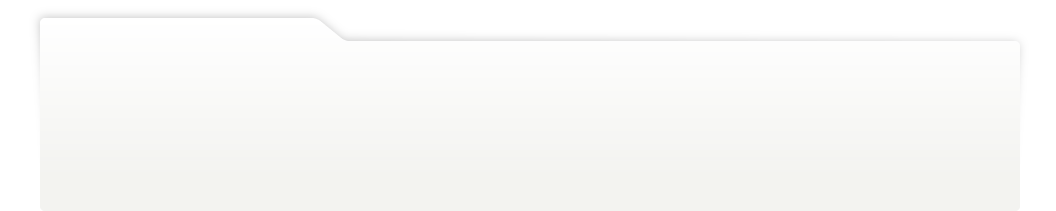
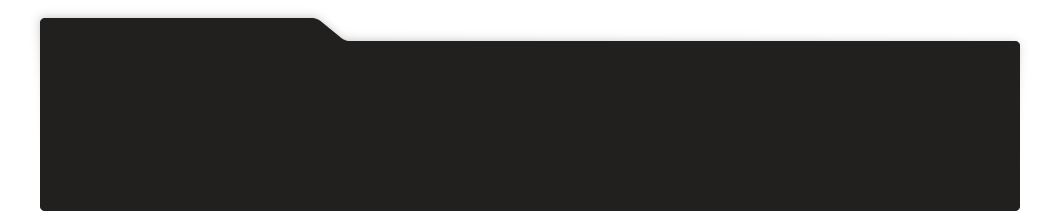
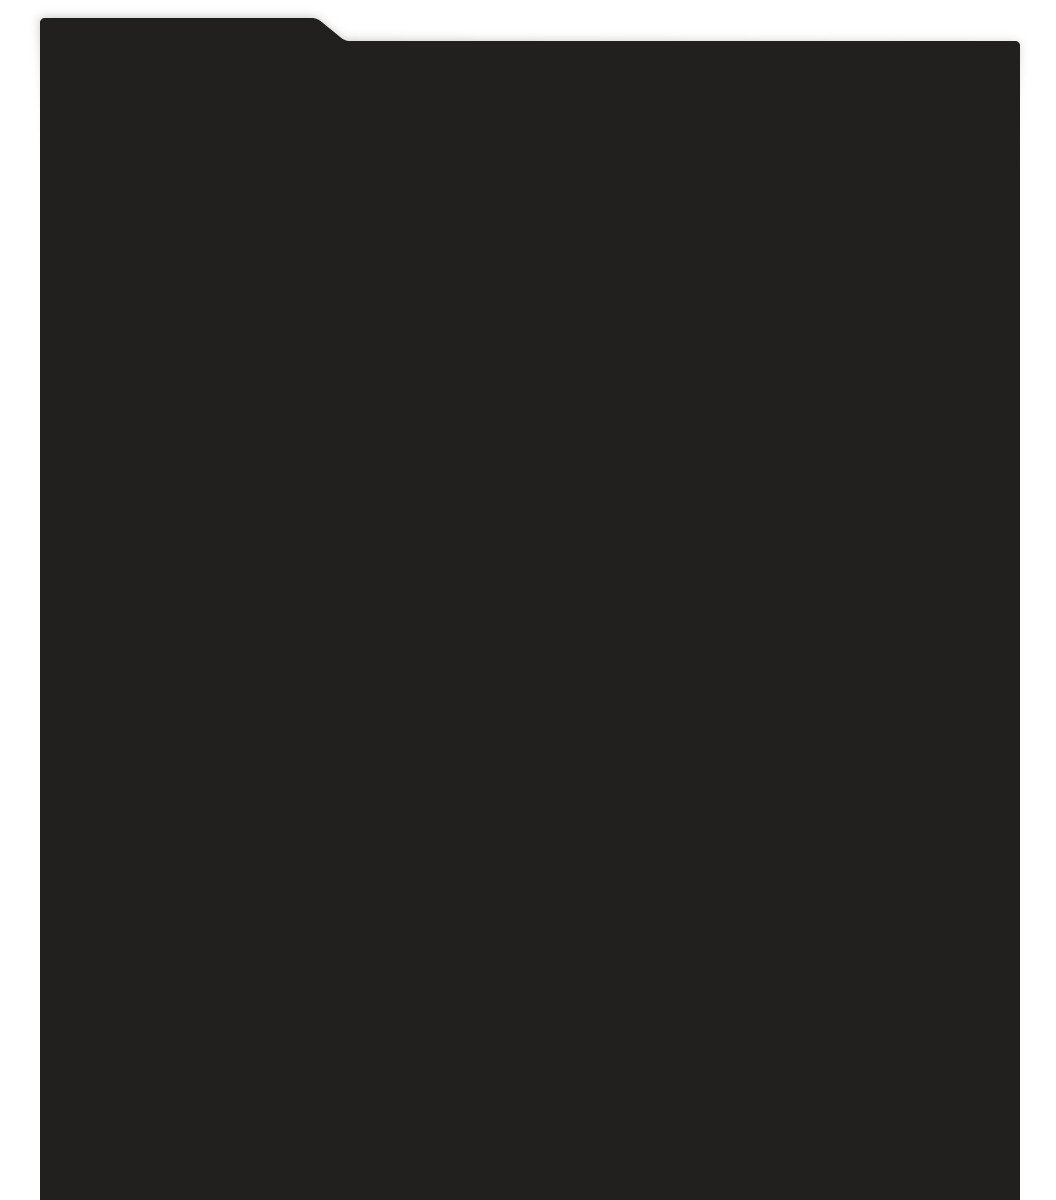
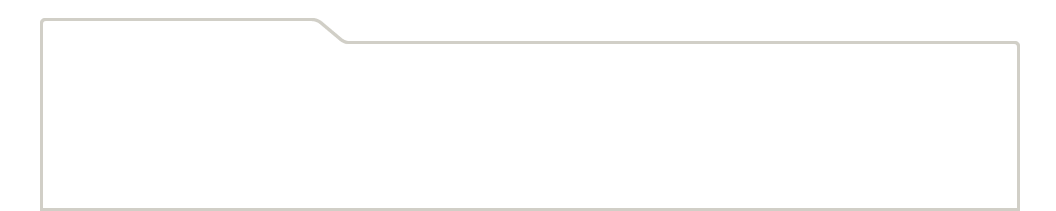
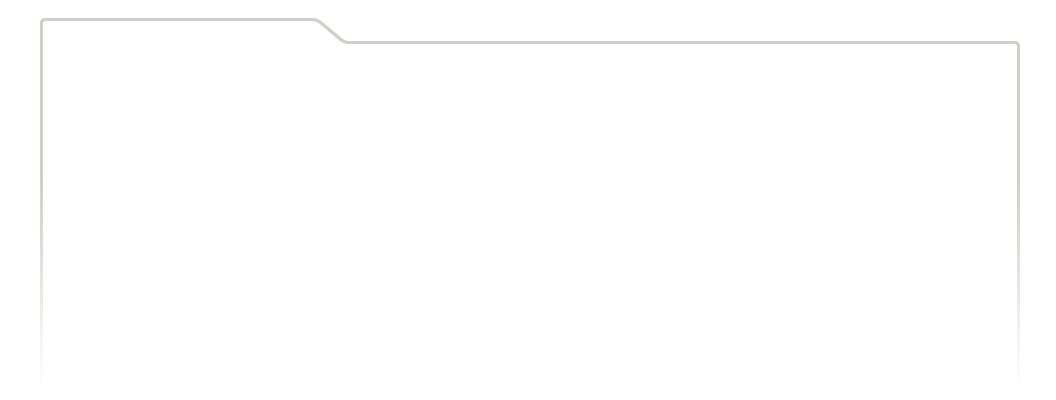
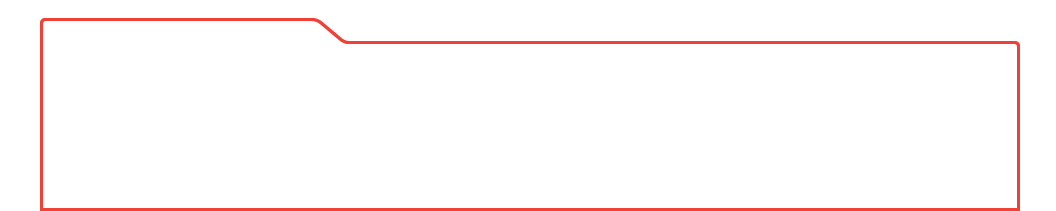
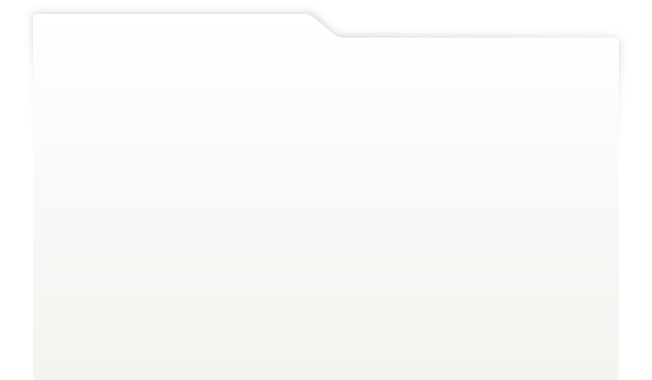
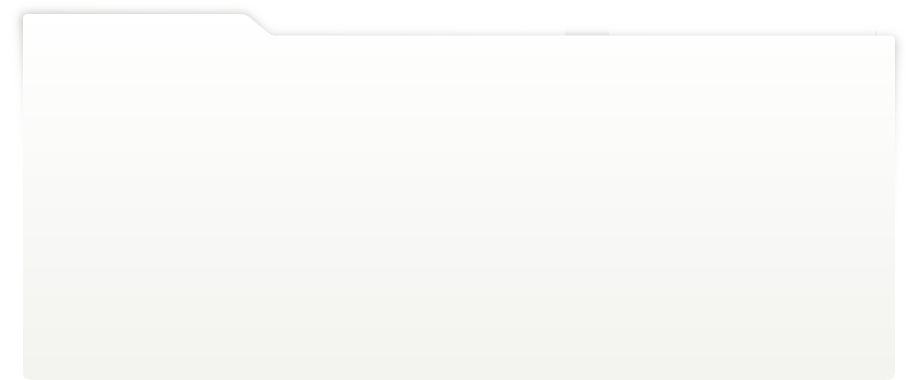
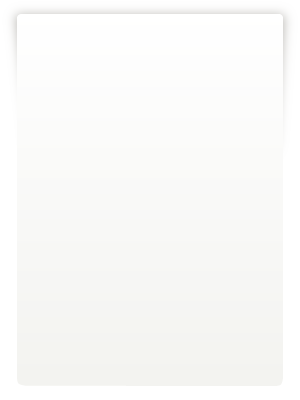
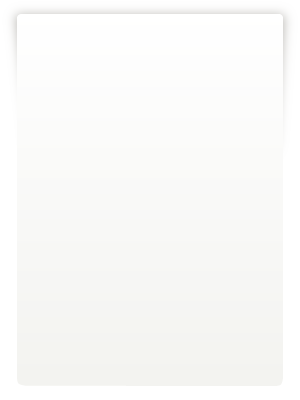
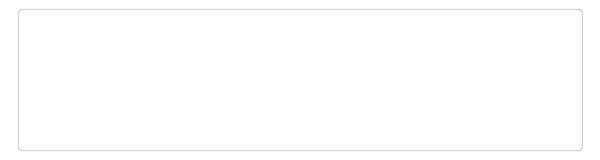
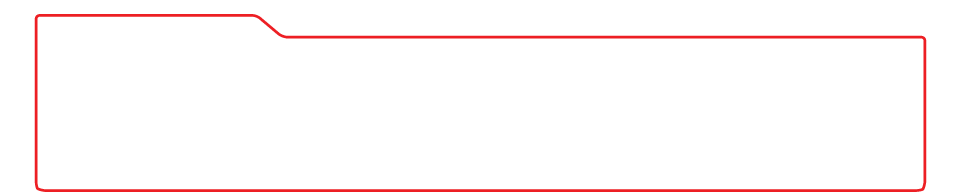
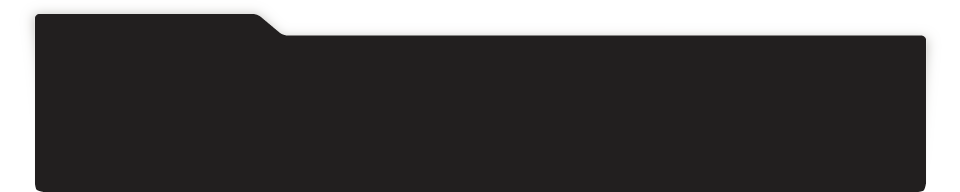
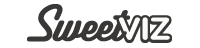
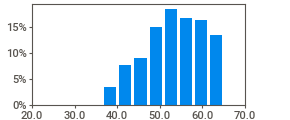
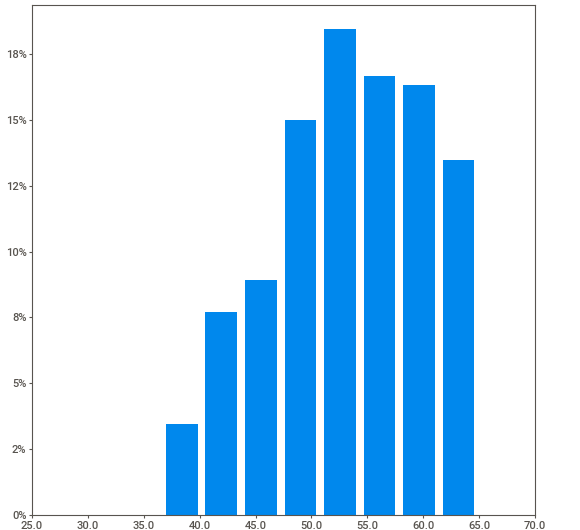
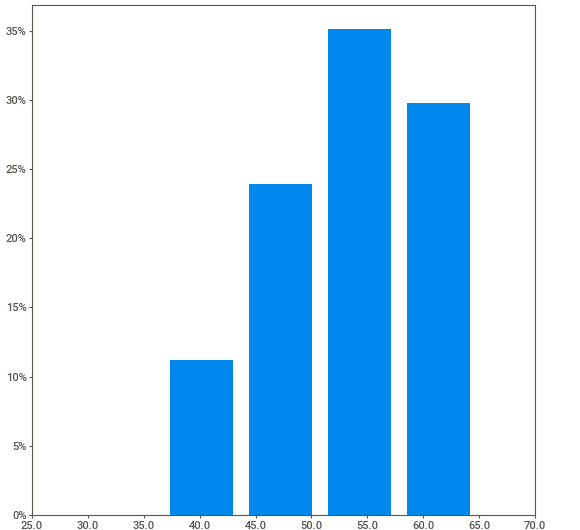
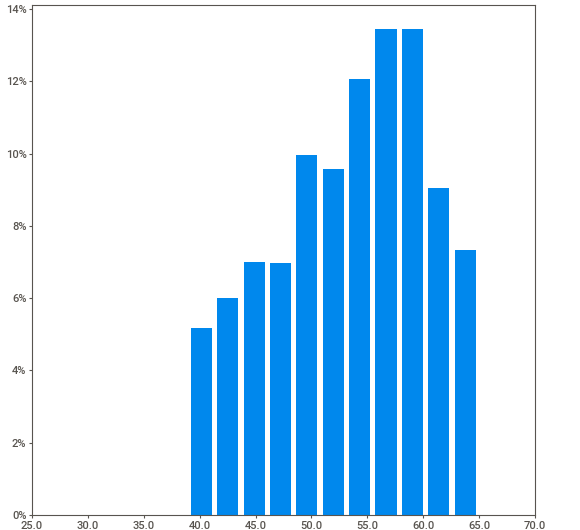
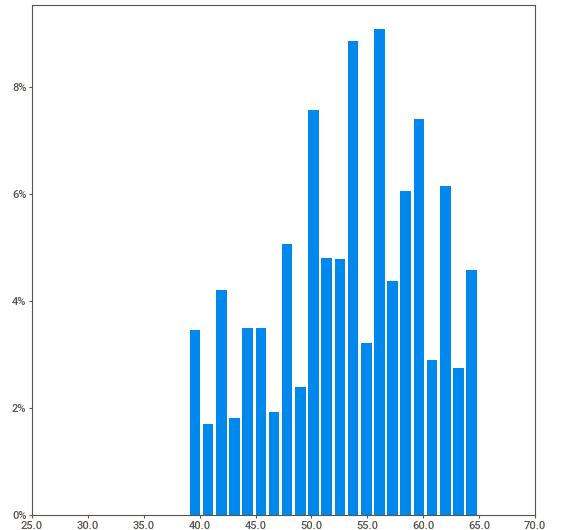
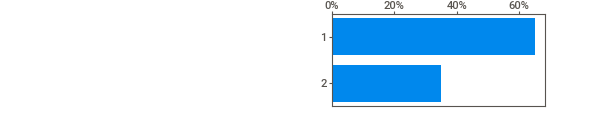
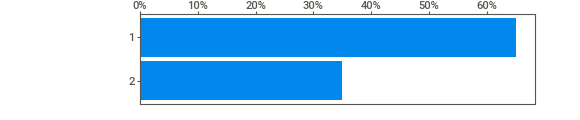
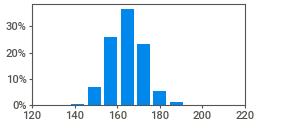
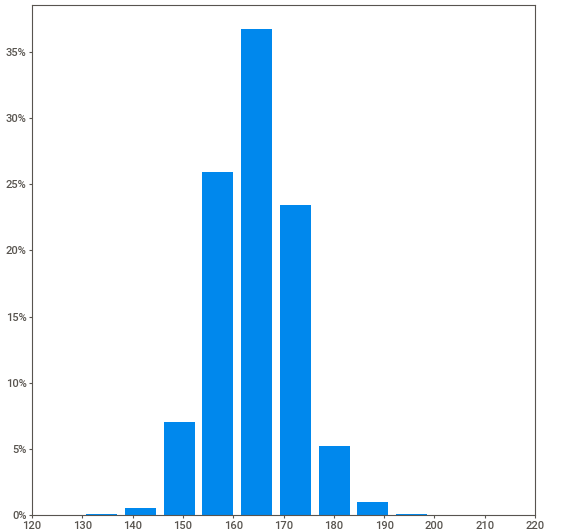
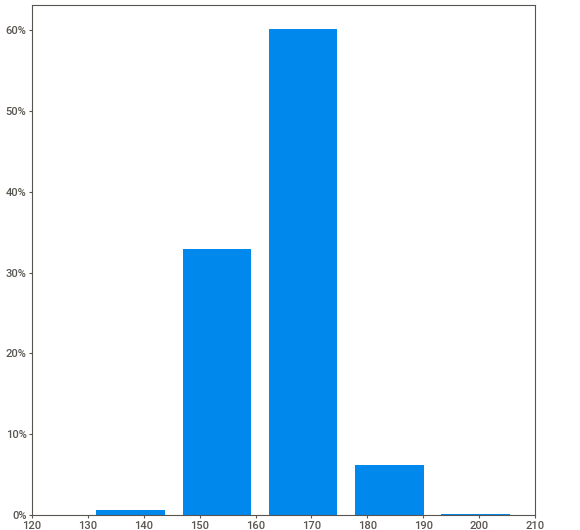
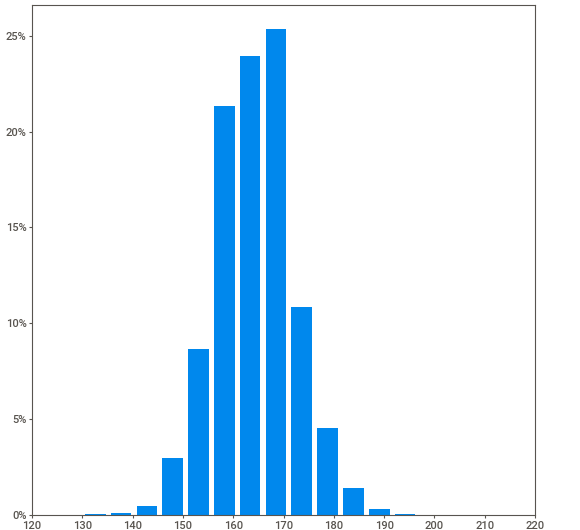
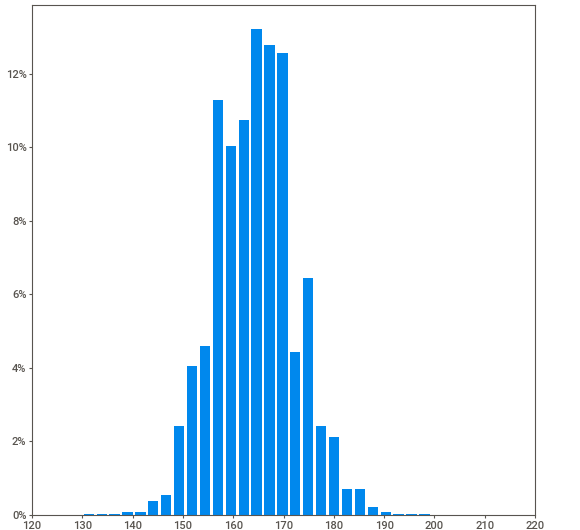
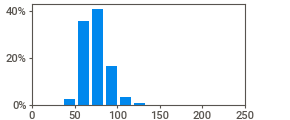
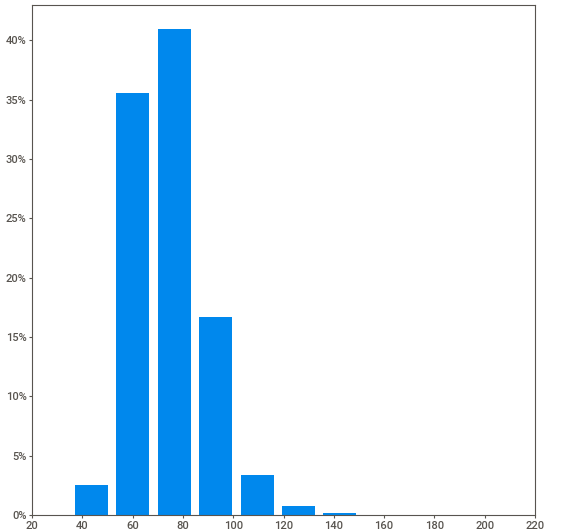
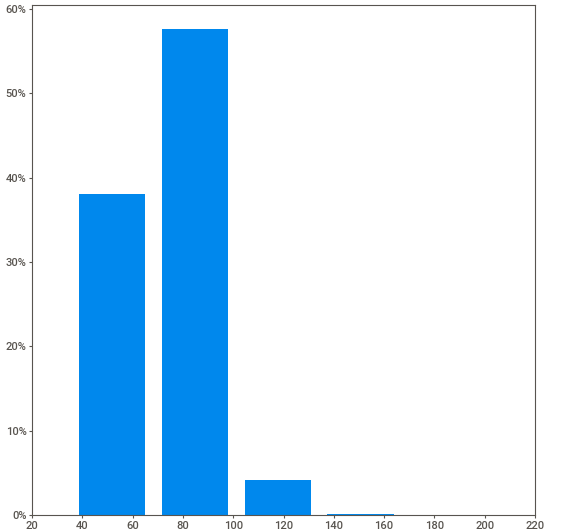
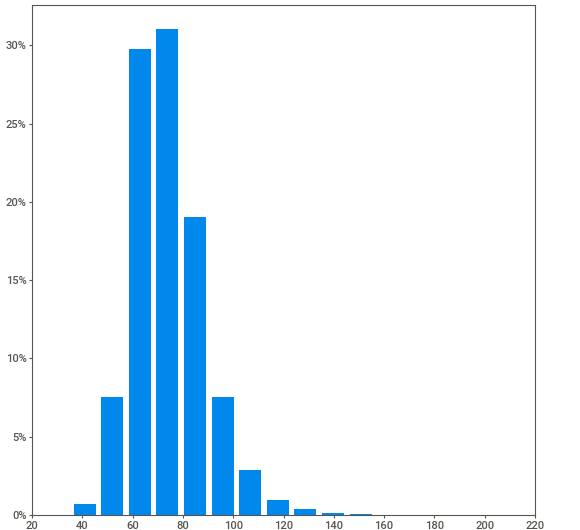
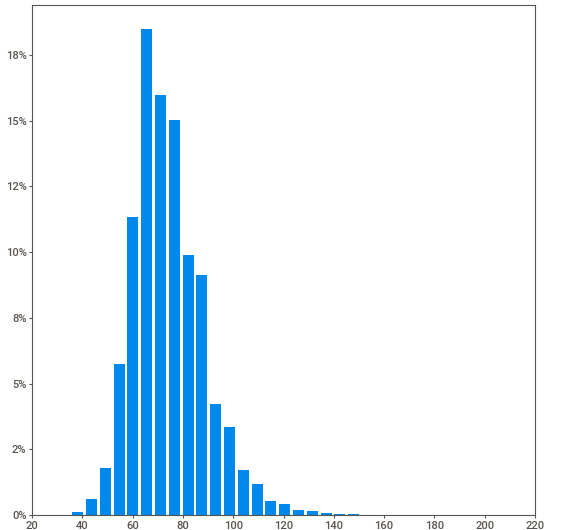
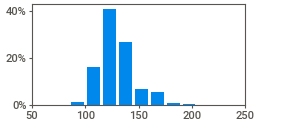
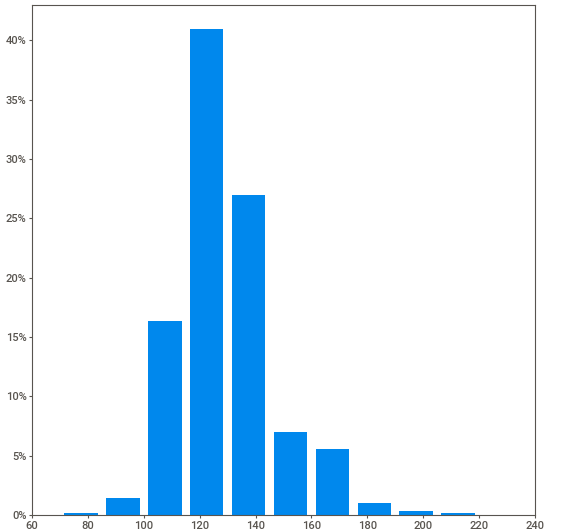
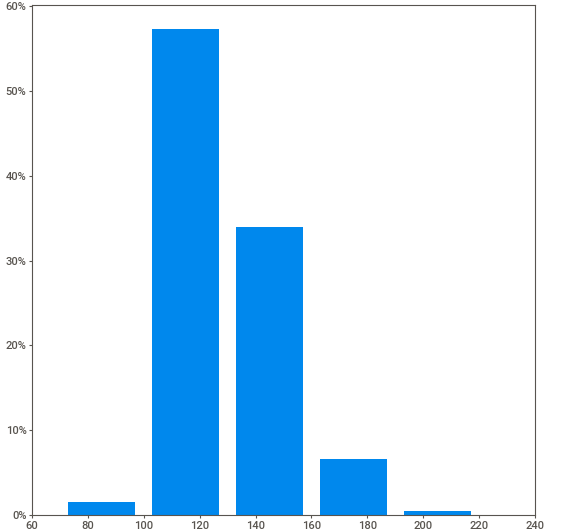
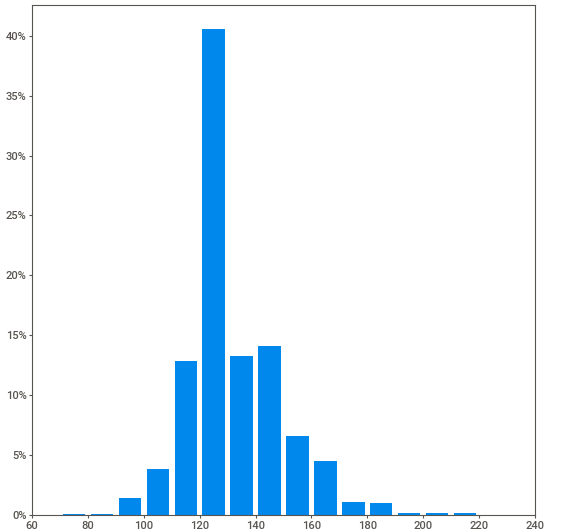
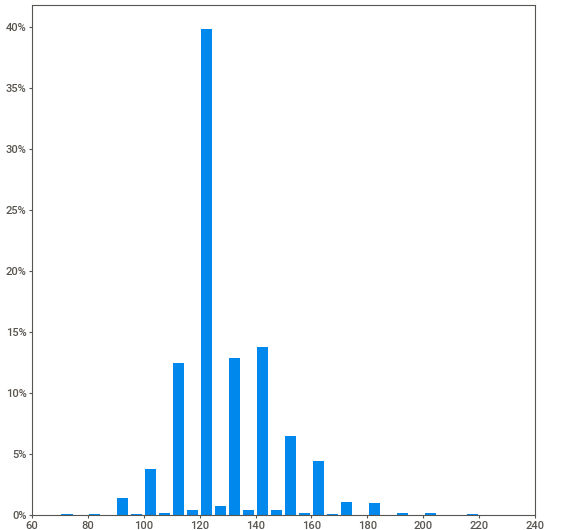
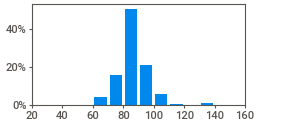
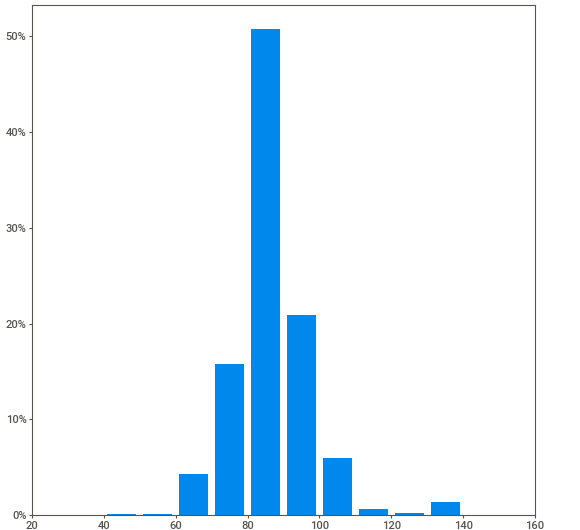
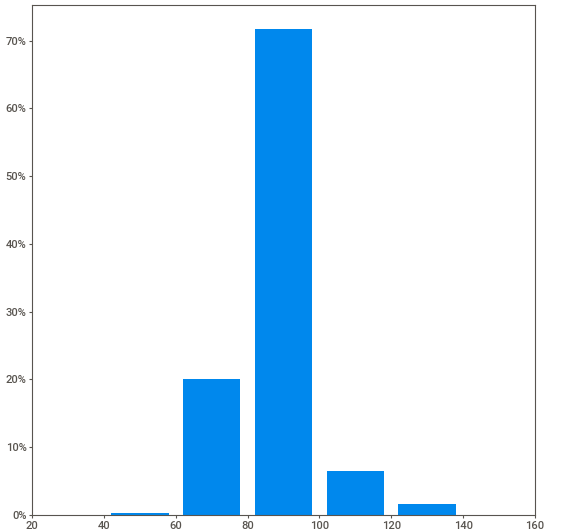
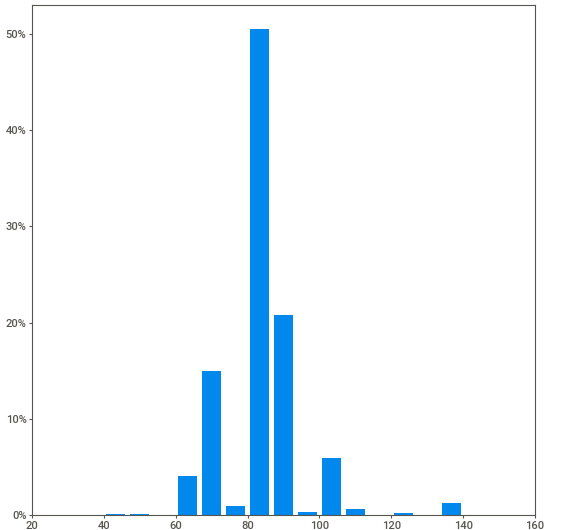
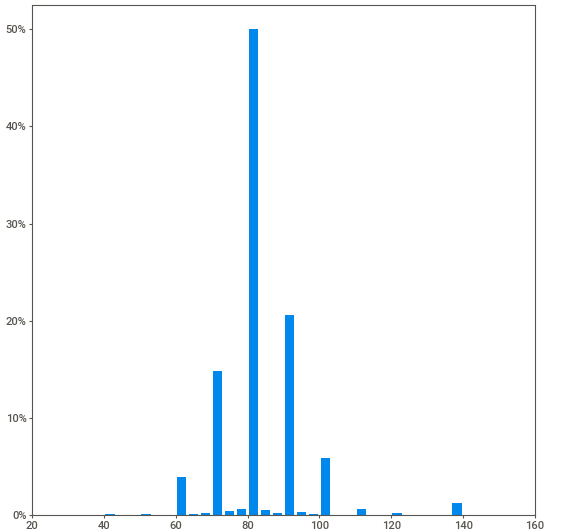
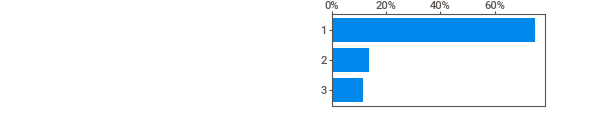
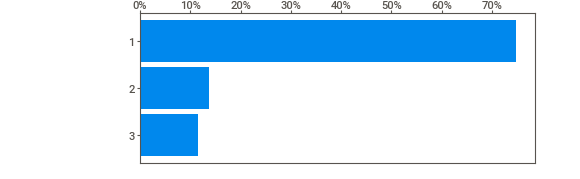
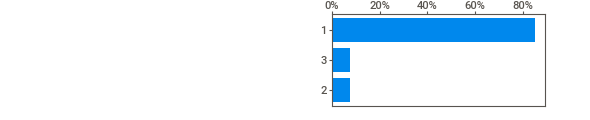
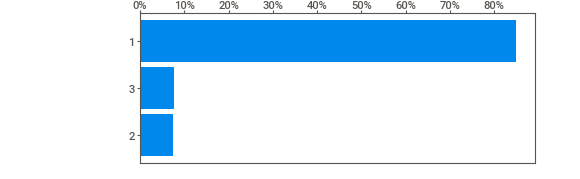
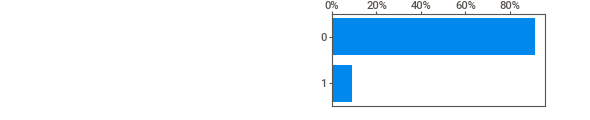
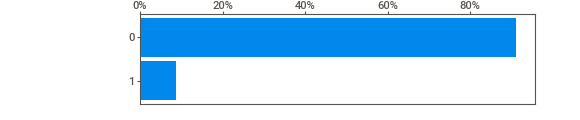
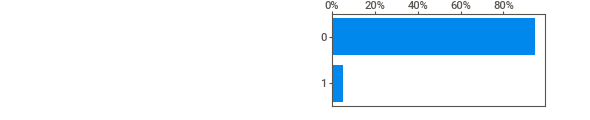
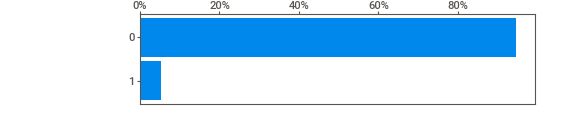
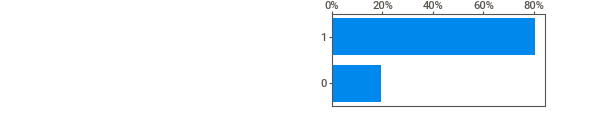
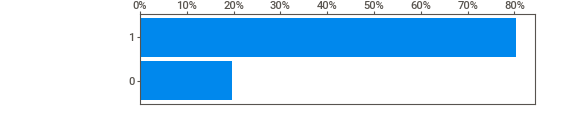
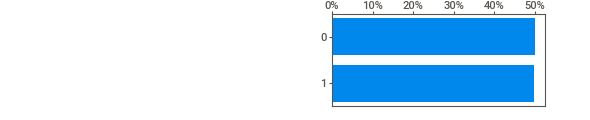
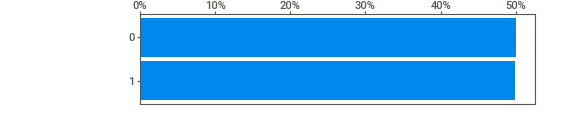
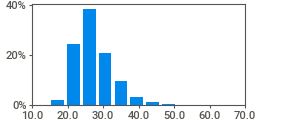
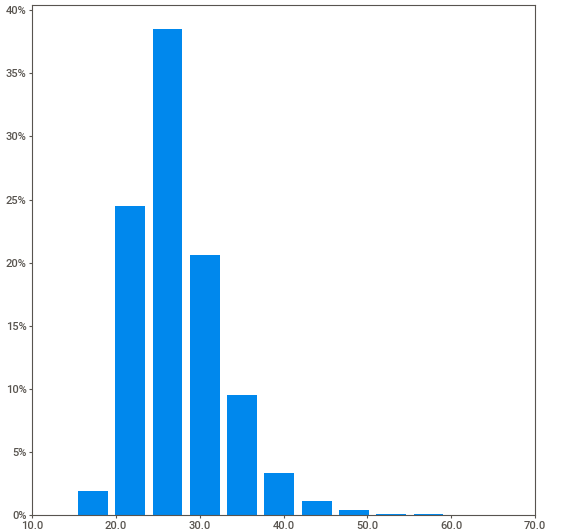
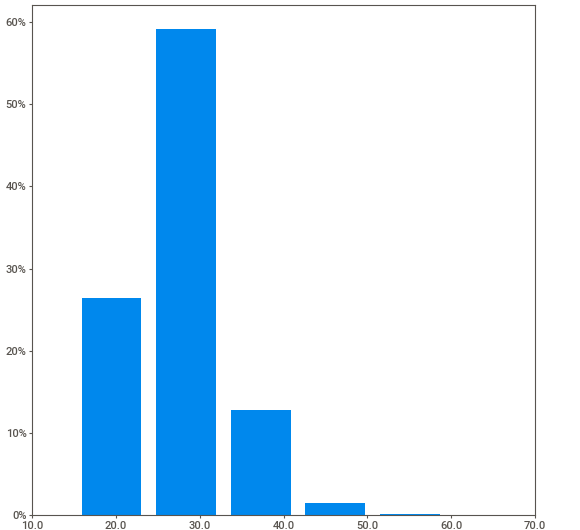
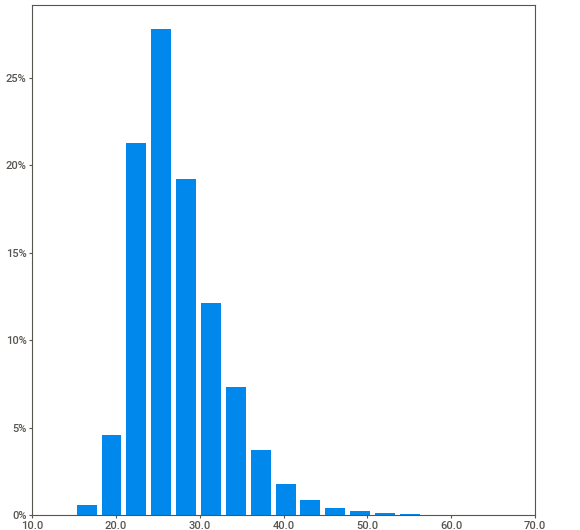
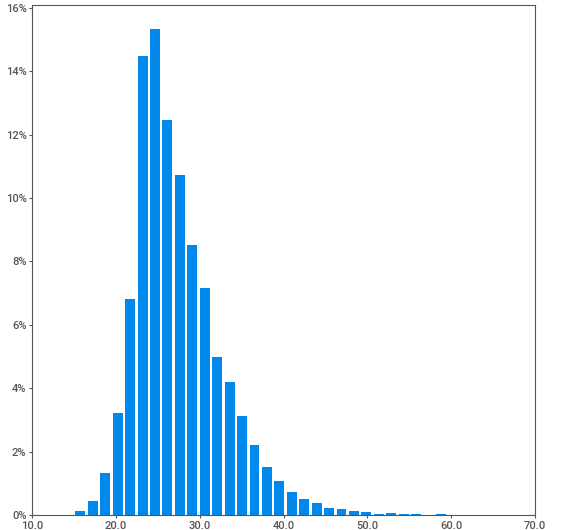
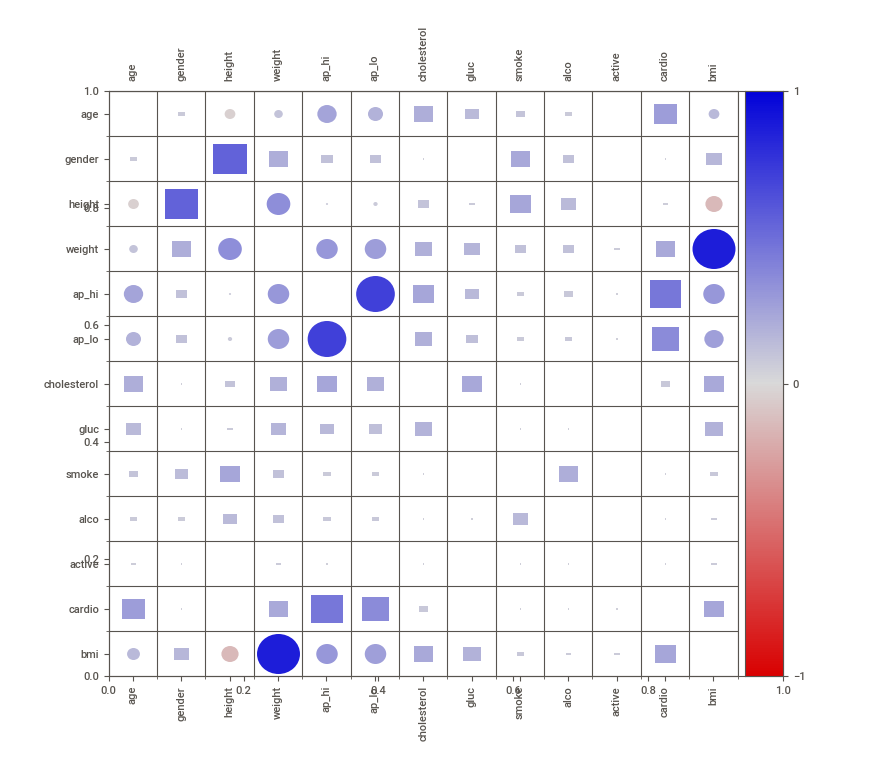
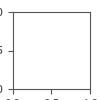

In [ ]:
# Generate the report
report = sv.analyze(df)

# Display the report in the notebook
report.show_notebook()

We can see, that the cardio column is perfectly balanced, which will come handy for the ML pipeline to avoid biases.

In [ ]:
# Creating a more visually appealing correlation matrix
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # to mask the upper triangle of the heatmap
plt.figure(figsize=(12, 8))
# Create the heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="seismic", mask = mask,
            vmin=-1, vmax=1, center=0,  # Set color scale limits and center
            linewidths=.5, cbar_kws={"shrink": .8})  #  Customize appearance

# Customize the plot (optional)
plt.title('Correlation Matrix of CVD Features', fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.yticks(rotation=0)

# Highlight our target variable
for label in plt.gca().get_yticklabels():
    if label.get_text() == 'cardio':
        label.set_fontweight('bold')
        label.set_fontsize(14)  # Adjust size as needed
        # label.set_color('red')  # Optional: Change color

plt.show()

###2.1&nbsp;Correlation Matrix Assessment

Based on the correlation matrix, we can observe the following relationships:

*   **Moderate Positive Correlation between Systolic (ap_hi) and Diastolic (ap_lo) Blood Pressure (0.69):** This is physiologically expected; individuals with higher systolic pressure tend to have higher diastolic pressure as well.
*   **Moderate Positive Correlations with `cardio`:**
    *   **`ap_hi` (0.43):** This is the *strongest* correlation with the target variable. High systolic blood pressure is a significant risk factor for cardiovascular disease.
    *   **`ap_lo` (0.32):**  High diastolic blood pressure is also a significant risk factor.
    *   **`cholesterol` (0.22):**  Higher cholesterol levels are associated with increased cardiovascular risk.
    *   **`age` (0.24):**  Older individuals are more likely to have cardiovascular disease. This is expected.
    * **`bmi` (0.19)**: Higher BMI is correlated.

*   **Relatively Weak Correlations with Other Features:** Most other features exhibit weak correlations with each other and with the target variable ('cardio'). This suggests that these factors might have more subtle or complex relationships with cardiovascular disease risk, or might be less directly influential than blood pressure, cholesterol, or BMI. The binary variables (smoke, alco, active) show almost no linear correlation with the other variables.

###2.2&nbsp;Visualizing correlations

In [ ]:
# For visualization, let's create a modified version of our df
df_plot = df.copy()
df_plot['age'] = df_plot['age'].astype(int)

#Creating average cardio risk
average_cardio_risk = df_plot.groupby('age')['cardio'].mean().reset_index()

fig = px.bar(x=average_cardio_risk['age'], y=average_cardio_risk['cardio'],
             title='The Risk of Cardiovascular Disease by Age',
             color=average_cardio_risk['age'],
             color_continuous_scale=px.colors.sequential.thermal_r ,
             labels={'x': 'Age', 'y': 'Average CVD Risk'})


fig.update_layout(
    height=500,
    width=800,
    xaxis=dict(range=[38, 65]),
    coloraxis_colorbar=dict(title='Age')
)

fig.show()

In [ ]:
# Convert cholesterol to a categorical variable with meaningful labels
df_plot['cholesterol'] = df_plot['cholesterol'].astype(str)  # Ensure it's treated as categorical
df_plot['cholesterol'] = df_plot['cholesterol'].replace({
    '1': 'Normal',
    '2': 'Above Normal',
    '3': 'Well Above Normal'
})

# Calculate average CVD risk for each age and cholesterol group
average_cvd_risk = df_plot.groupby(['age', 'cholesterol'])['cardio'].mean().reset_index()

fig = px.bar(
    average_cvd_risk,
    x='age',
    y='cardio',
    color='cholesterol',
    barmode='group',
    title="The Risk of Cardiovascular Disease by Age and Cholesterol Level",
    labels={'age': 'Age', 'cardio': 'Average CVD Risk', 'cholesterol': 'Cholesterol Level'},
    color_discrete_map={
    'Normal': '#00CC96',        # Green shade
    'Above Normal': '#636EFA',  # Blue shade
    'Well Above Normal': '#EF553B'  # Red shade
}
)

# Customize the layout
fig.update_layout(
    height=500,
    width=1800,
    xaxis=dict(range=[38, 65])
)

# Show the figure
fig.show()



We can see, that the influence of cholesterol levels on CVD risk appears to diminish with increasing age.
  * In younger age groups (e.g., 40–50), there is a more pronounced difference in CVD risk between individuals with "Normal" and "Well Above Normal" cholesterol levels.
  * In older age groups (e.g., 60+), the gap between cholesterol categories narrows, suggesting that other factors may play a larger role in determining CVD risk at advanced ages.

## **3.&nbsp;Baseline ML models**



### 3.1&nbsp;Split and Scale data

In [ ]:
# 1.Perpare features and target variable
X = df.drop(['cardio', 'height', 'weight'], axis=1) #Height and Weight is dropped since we added BMI to our data- this helps to reduce data complexity
y = df['cardio']

# 2.Split into training and a temporary holdout set (for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True, stratify=y)

# 3.Split the temporary holdout set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (48652, 10)
Validation set size: (10425, 10)
Test set size: (10426, 10)


While some models (tree-based) are inherently robust to feature scale differences, others converge more slowly or fail entirely due to imbalanced gradients, or their regularization penalties are applied unevenly, leading to biased results. For this reason, I will create a z-scaled version for each X-dataset:

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using the same scaling parameters
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

A kernel for the same dataset [on Kaggle](https://www.kaggle.com/code/vbmokin/20-models-for-cardiovascular-disease-prediction/notebook) have explored 20 different models, and reported their train and test scores respectively. I am going to select a few of the best performing ones, while taking new evaluation metrics into consideration, which are more suitable than accuracy:


I will select 5 models to showcase baseline performance before tuning. Score_diff was the difference between the test, and training sets accuracy.

1. **LGBMClassifier** (Test Score: 73.00) - minimal
   overfitting (Score_diff: 0.29). A gradient boosting framework that uses tree-based learning algorithms.
   It is known for its efficiency and scalability, making it suitable for large datasets
   and complex tasks.

2. **Logistic Regression** (Test Score: 72.85) - Chosen for its balance of simplicity and solid
   performance with low overfitting (Score_diff: 0.45). As a linear model, it provides an
   interpretable baseline that's computationally efficient.

3. **RidgeClassifier** (Test Score: 72.58) - Selected for its strong performance with very low
   overfitting (Score_diff: 0.24). This regularized linear model that applies L2 regularization to prevent overfitting- handles multicollinearity well
   and offers good stability.

4. **AdaBoostClassifier** (Test Score: 71.53) - An ensemble method that combines multiple weak classifiers, typically
   decision trees, to create a strong classifier. It adjusts weights iteratively to focus on
   difficult-to-classify instances
   with minimal overfitting (Score_diff: 0.25).

5. **XGBClassifier** (Test Score: 73.09) - Despite showing some overfitting (Score_diff: 7.23),
   this model achieved one of the highest test scores. It has significant potential for
   improvement through proper regularization during tuning.

This combination provides a comprehensive baseline to demonstrate both
current performance and opportunities for optimization.



###3.2&nbsp;Evaluation metrics

Since our dataset is perfectly balanced regarding the output classes, we can consider the following evaluation metrics for the models:

- **Accuracy**
  - Measures overall correctness of predictions.
  - Easy to interpret.
  - Good baseline metric for balanced datasets.

- **Recall (Sensitivity)**
  - Measures proportion of actual positive cases correctly identified.
  - Crucial when missing a positive diagnosis is dangerous.

- **F1 Score**
  - Harmonic mean of Precision and Recall.
  - Provides balanced measure, useful when false positives and negatives are equally important.

- **ROC-AUC**
  - Measures model's ability to distinguish between classes across all thresholds.
  - Useful for comparing different models or selecting optimal decision thresholds.

- **Log Loss (Cross-Entropy)**
  - Measures how closely predicted probabilities match actual labels.
  - Penalizes incorrect predictions made with high confidence; useful for probabilistic evaluation.

### 3.3&nbsp;Train and test with baseline parameters

In [ ]:
# Set random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

# Define models
models = {
    "LGBMClassifier": LGBMClassifier(random_state=random_seed,verbose=-1),
    "RidgeClassifier": RidgeClassifier(random_state=random_seed),
    "LogisticRegression": LogisticRegression(random_state=random_seed,max_iter=1000),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=random_seed),
    "XGBClassifier": XGBClassifier(random_state=random_seed)
}

# Initialize results dictionary for storing metrics and plots
results = {}

# Train each model
for model_name, model in models.items():
    model.fit(X_train, y_train)

In [ ]:
# Calculate and display metrics
baseline_metrics_df = pd.DataFrame(columns=["Model", "Accuracy", "Recall", "Precision", "F1 Score", "ROC-AUC", "Cross-Entropy"])
roc_data = {}

for model_name, model in models.items():
    # Make predictions for this specific model
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For RidgeClassifier which doesn't support predict_proba directly
        y_pred_proba = model.decision_function(X_test)

    # Calculate metrics using this model's predictions
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cross_entropy = log_loss(y_test, y_pred_proba)

    # Append a new row as a dictionary to the DataFrame
    baseline_metrics_df.loc[len(baseline_metrics_df)] = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Cross-Entropy": cross_entropy
    }

    # Store ROC curve data for plotting later
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, roc_auc)

# Display the metrics table
baseline_metrics_df.set_index("Model",inplace=True)
baseline_metrics_df.sort_values(by="Accuracy", ascending=False, inplace=True)
baseline_metrics_df.style.format(precision=4)



,Accuracy,Recall,Precision,F1 Score,ROC-AUC,Cross-Entropy
Model,,,,,,
LGBMClassifier,0.7362,0.6980,0.7554,0.7255,0.7989,0.5442
XGBClassifier,0.7297,0.6935,0.7472,0.7194,0.7930,0.5547
LogisticRegression,0.7252,0.6719,0.7517,0.7095,0.7886,0.5636
AdaBoostClassifier,0.7252,0.6505,0.7643,0.7028,0.7910,0.5957
RidgeClassifier,0.7229,0.6590,0.7551,0.7038,0.7879,6.6994


In [ ]:
# Create overlay of ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve for each model on the same axes
for model_name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name = model_name,
        ax=ax,
    )

# Add styling
plt.title("ROC Curves for All Baseline Models", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.show()


## **4.&nbsp;Hyperparameter Tuning with Bayesian Optimization**

In this section, I'll explore Bayesian Optimization (BO) to efficiently search through hyperparameter spaces and find optimal configurations for our models. Unlike grid or random search, Bayesian Optimization uses probabilistic models to intelligently navigate the hyperparameter space, focusing computational resources on the most promising regions.


1.   **Define search spaces** *italicized text*: Create parameter ranges for each model (learning rates, tree depths, regularization strengths, etc.)

2.   **Objective function**: Evaluate model performance for each parameter combination. Here we can define based on what metric we want to optimize.

3. **Bayesian optimization loop**:

  * Build a probabilistic model of the objective function

  * Select promising parameters to evaluate next

  * Update the model with new results

  * Repeat until reaching maximum evaluations


In [ ]:
#@title 4.1. Define hyperparameter spaces for each model
# 1. LGBMClassifier
lgbm_param_space = {
    'learning_rate': hp.loguniform('lgbm_learning_rate', np.log(0.01), np.log(0.3)),
    'num_leaves': hp.quniform('lgbm_num_leaves', 20, 150, 1),
    'max_depth': hp.quniform('lgbm_max_depth', 3, 10, 1),
    'n_estimators': hp.choice('lgbm_n_estimators', [100, 200, 300, 500]),
    'min_child_samples': hp.quniform('lgbm_min_child_samples', 5, 50, 1),
    'subsample': hp.uniform('lgbm_subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('lgbm_colsample_bytree', 0.6, 1.0),
    'random_state': 42,
    'verbose': -1
}

# 2. RidgeClassifier
ridge_param_space = {
    'alpha': hp.loguniform('ridge_alpha', np.log(0.01), np.log(100.0)),
    'solver': hp.choice('ridge_solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
    'random_state': 42
}

# 3. LogisticRegression
logreg_param_space = {
    'C': hp.loguniform('logreg_C', np.log(0.01), np.log(10.0)),
    'solver': hp.choice('logreg_solver', ['liblinear', 'saga']),
    'max_iter': 10000,
    'penalty': hp.choice('logreg_penalty', ['l1', 'l2']),
    'tol': hp.choice('logreg_tol', [0.01, 0.1, 0.5]),
    'random_state': 42,
}

# 4. AdaBoostClassifier
adaboost_param_space = {
    'n_estimators': hp.choice('ada_n_estimators', [50, 100, 200, 300]),
    'learning_rate': hp.loguniform('ada_learning_rate', np.log(0.01), np.log(1.0)),
    'random_state': 42
}

# 5. XGBClassifier
xgb_param_space = {
    'learning_rate': hp.loguniform('xgb_learning_rate', np.log(0.01), np.log(0.3)),
    'max_depth': hp.quniform('xgb_max_depth', 3, 10, 1),
    'n_estimators': hp.choice('xgb_n_estimators', [100, 200, 300, 500]),
    'gamma': hp.loguniform('xgb_gamma', np.log(0.0001), np.log(5.0)),
    'min_child_weight': hp.loguniform('xgb_min_child_weight', np.log(1), np.log(100)),
    'subsample': hp.uniform('xgb_subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('xgb_colsample_bytree', 0.6, 1.0),
    'random_state': 42
}

# Combine all parameter spaces into a dictionary
param_spaces = {
    "LGBMClassifier": lgbm_param_space,
    "RidgeClassifier": ridge_param_space,
    "LogisticRegression": logreg_param_space,
    "AdaBoostClassifier": adaboost_param_space,
    "XGBClassifier": xgb_param_space
}


An important consideration is to asess which evaluation metric do we want to optimize. The relative costs of misdiagnosis aren't definitively established, as is the case with our cardiovascular dataset. I chose to optimize the F1 score because it provides a balanced approach to both false positives and false negatives. In this clinical context, both error types carry significant consequences: false negatives mean patients with cardiovascular disease go untreated, potentially facing life-threatening events, while false positives could lead to unnecessary medication with potential side effects and psychological burden.

In [ ]:
#@title 4.2. Set up objective function
# Define objective function for hyperopt
def objective(params, model_class, X_train, y_train, X_val, y_val):
    # Convert any integer parameters from float to int
    for param_name in params:
        if param_name.endswith('max_depth') or param_name.endswith('n_estimators') or param_name.endswith('leaves') or\
           param_name.endswith('min_child_samples') or param_name.endswith('max_iter'):
            params[param_name] = int(params[param_name])

    # Create and train model with the given parameters
    model = model_class(**params)
    model.fit(X_train, y_train)

    # Predict on validation set
    y_pred = model.predict(X_val)

    # Calculate F1 score (we want to maximize, so return negative)
    f1 = f1_score(y_val, y_pred)

    return {'loss': -f1, 'status': STATUS_OK, 'model': model}


Next, the optimize_model function takes care of the hyperparameter optimization process for each model. Each optimization run now produce the same "best parameters" when executed with the same random seed, experimentation reproducible.

### 4.3. Optimization algorithm

In [ ]:
def optimize_model(model_class, param_space, X_train, y_train, X_val, y_val, max_evals=50):
    trials = Trials()

    # Define the objective function for this specific model
    def model_objective(params):
        return objective(params, model_class, X_train, y_train, X_val, y_val)

    # Run the optimization
    best = fmin(
      fn=model_objective,
      space=param_space,
      algo=tpe.suggest,
      max_evals=max_evals,
      trials=trials,
      rstate=np.random.default_rng(42) # This is crucial to get the same "best parameters" each time
      )

    # Get the best model from trials
    best_trial = sorted(trials.trials, key=lambda x: x['result']['loss'])[0]
    best_model = best_trial['result']['model']
    best_f1 = -best_trial['result']['loss']  # Convert back to positive

    model_name = model_class.__name__
    print(f"\nBest {model_name} F1 Score: {best_f1:.4f}")
    print(f"Best {model_name} Parameters:")
    for param, value in best.items():
        print(f"  {param}: {value}")

    return best_model, best, best_f1

In [ ]:
# Dictionary to store optimization results
optimization_results = {}

# Map model names to classes
model_classes = {
    "LGBMClassifier": LGBMClassifier,
    "RidgeClassifier": RidgeClassifier,
    "LogisticRegression": LogisticRegression,
    "AdaBoostClassifier": AdaBoostClassifier,
    "XGBClassifier": XGBClassifier
}

# Run optimization for each model
for model_name, model_class in model_classes.items():
    print(f"\n{'='*50}")
    print(f"Optimizing {model_name}...")
    print(f"{'='*50}")

    # Optimize the model
    best_model, best_params, best_f1 = optimize_model(
        model_class=model_class,
        param_space=param_spaces[model_name],
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        max_evals=10  # Number of iterations for Bayesian Optimization
    )

    # Map indices from hp.choice back to their actual values using space_eval
    best_params_actual = space_eval(param_spaces[model_name], best_params)

    # Store results
    optimization_results[model_name] = {
        'model': best_model,
        'params': best_params_actual,  # Save actual parameter values
        'f1_score': best_f1
    }
# Save the best parameters for each model into a dictionary for later use
best_hyperparameters = {model: results['params'] for model, results in optimization_results.items()}



Optimizing LGBMClassifier...
100%|██████████| 10/10 [00:37<00:00,  3.79s/trial, best loss: -0.7311806256306761]

Best LGBMClassifier F1 Score: 0.7312
Best LGBMClassifier Parameters:
  lgbm_colsample_bytree: 0.7406073781487617
  lgbm_learning_rate: 0.0328015872536063
  lgbm_max_depth: 10.0
  lgbm_min_child_samples: 31.0
  lgbm_n_estimators: 0
  lgbm_num_leaves: 120.0
  lgbm_subsample: 0.8893193614697442

Optimizing RidgeClassifier...
100%|██████████| 10/10 [00:09<00:00,  1.00trial/s, best loss: -0.7072589831210521]

Best RidgeClassifier F1 Score: 0.7073
Best RidgeClassifier Parameters:
  ridge_alpha: 20.910216502643813
  ridge_solver: 3

Optimizing LogisticRegression...
100%|██████████| 10/10 [00:08<00:00,  1.13trial/s, best loss: -0.7135101915394858]

Best LogisticRegression F1 Score: 0.7135
Best LogisticRegression Parameters:
  logreg_C: 0.7128243944571562
  logreg_penalty: 0
  logreg_solver: 0
  logreg_tol: 0

Optimizing AdaBoostClassifier...
100%|██████████| 10/10 [00:45<00:00,  4.

### 4.4. Display best hyperparameters for each model

In [ ]:
# Display the saved hyperparameters with actual values
print("\nBest Hyperparameters for Each Model:")
for model_name, params in best_hyperparameters.items():
    print(f"\n{model_name}:")
    for param, value in params.items():
        print(f"  {param}: {value}")


Best Hyperparameters for Each Model:

LGBMClassifier:
  colsample_bytree: 0.7406073781487617
  learning_rate: 0.0328015872536063
  max_depth: 10.0
  min_child_samples: 31.0
  n_estimators: 100
  num_leaves: 120.0
  random_state: 42
  subsample: 0.8893193614697442
  verbose: -1

RidgeClassifier:
  alpha: 20.910216502643813
  random_state: 42
  solver: lsqr

LogisticRegression:
  C: 0.7128243944571562
  max_iter: 10000
  penalty: l1
  random_state: 42
  solver: liblinear
  tol: 0.01

AdaBoostClassifier:
  learning_rate: 0.9862213949016526
  n_estimators: 200
  random_state: 42

XGBClassifier:
  colsample_bytree: 0.6621422616094998
  gamma: 2.8395546845661017
  learning_rate: 0.0559415830946173
  max_depth: 9.0
  min_child_weight: 1.4571151842793908
  n_estimators: 100
  random_state: 42
  subsample: 0.8796314378966033


### 4.5. Predict with optimized parameters

In [ ]:
# Train models with optimized hyperparameters
trained_models = {}

for model_name, params in best_hyperparameters.items():
    print(f"\n{'='*50}")
    print(f"Retraining {model_name} with optimized hyperparameters...")
    print(f"{'='*50}")

    # Ensure integer parameters are cast correctly for models that require them
    for param in ['num_leaves', 'max_depth', 'n_estimators', 'min_child_samples']:
        if param in params:
            params[param] = int(params[param])

    # Instantiate the model with optimized parameters
    model_class = model_classes[model_name]
    optimized_model = model_class(**params)

    # Train the model on the training set
    optimized_model.fit(X_train, y_train)

    # Store the trained model for later use
    trained_models[model_name] = optimized_model


Retraining LGBMClassifier with optimized hyperparameters...

Retraining RidgeClassifier with optimized hyperparameters...

Retraining LogisticRegression with optimized hyperparameters...

Retraining AdaBoostClassifier with optimized hyperparameters...

Retraining XGBClassifier with optimized hyperparameters...


In [ ]:
# Initialize data structures for storing metrics
optimized_metrics_df = pd.DataFrame(columns=["Model", "Accuracy", "Recall", "Precision", "F1 Score", "ROC-AUC", "Cross-Entropy"])
# Loop through trained models to make predictions and calculate metrics
for model_name, optimized_model in trained_models.items():
    # Make predictions for this specific model
    y_pred = optimized_model.predict(X_test)

    # Handle probabilities for metrics like ROC-AUC and Cross-Entropy Loss
    if hasattr(optimized_model, "predict_proba"):
        y_pred_proba = optimized_model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba, use decision_function
        y_pred_proba = optimized_model.decision_function(X_test)

    # Calculate metrics using this model's predictions
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cross_entropy = log_loss(y_test, y_pred_proba)

    # Append a new row as a dictionary to the DataFrame
    optimized_metrics_df.loc[len(optimized_metrics_df)] = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Cross-Entropy": cross_entropy
    }

In [ ]:
#@title Compare with baseline parameters
# Format the optimized metrics table
optimized_metrics_df.set_index("Model", inplace=True)

# Get the order of models from the baseline metrics DataFrame
baseline_model_order = baseline_metrics_df.index.tolist()

# Reindex the optimized metrics DataFrame to match the baseline order
# This will only include models that exist in both DataFrames
common_models = set(baseline_metrics_df.index).intersection(set(optimized_metrics_df.index))
ordered_models = [model for model in baseline_model_order if model in common_models]
optimized_metrics_df = optimized_metrics_df.reindex(ordered_models)

# Display both tables for comparison
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

print("\nBASELINE MODEL METRICS:")
display(baseline_metrics_df.style.format(precision=4))

print("\nOPTIMIZED MODEL METRICS:")
display(optimized_metrics_df.style.format(precision=4))

# Calculate and display improvement percentages
print("\n" + "="*80)
print("PERFORMANCE IMPROVEMENT AFTER OPTIMIZATION")
print("="*80)

# Create a comparison DataFrame with the same order as baseline
comparison_df = pd.DataFrame(index=ordered_models)

# Calculate percentage improvements for each metric and model
for metric in ["Accuracy", "Recall", "Precision", "F1 Score", "ROC-AUC"]:
    comparison_df[metric] = np.nan

    for model in ordered_models:
        baseline_value = baseline_metrics_df.loc[model, metric]
        optimized_value = optimized_metrics_df.loc[model, metric]

        # Calculate percentage improvement
        pct_change = ((optimized_value - baseline_value) / baseline_value) * 100
        comparison_df.loc[model, metric] = pct_change

# For Cross-Entropy, lower is better, so invert the percentage
if "Cross-Entropy" in baseline_metrics_df.columns and "Cross-Entropy" in optimized_metrics_df.columns:
    comparison_df["Cross-Entropy"] = np.nan
    for model in ordered_models:
        baseline_value = baseline_metrics_df.loc[model, "Cross-Entropy"]
        optimized_value = optimized_metrics_df.loc[model, "Cross-Entropy"]

        # For Cross-Entropy, a decrease is an improvement
        pct_change = ((baseline_value - optimized_value) / baseline_value) * 100
        comparison_df.loc[model, "Cross-Entropy"] = pct_change

# Display the comparison
print("\nPercentage Improvement (%):")
display(comparison_df.style.format(precision=2).background_gradient(cmap='RdYlGn', axis=None))


MODEL PERFORMANCE COMPARISON

BASELINE MODEL METRICS:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC,Cross-Entropy
Model,,,,,,
LGBMClassifier,0.7362,0.6980,0.7554,0.7255,0.7989,0.5442
XGBClassifier,0.7297,0.6935,0.7472,0.7194,0.7930,0.5547
LogisticRegression,0.7252,0.6719,0.7517,0.7095,0.7886,0.5636
AdaBoostClassifier,0.7252,0.6505,0.7643,0.7028,0.7910,0.5957
RidgeClassifier,0.7229,0.6590,0.7551,0.7038,0.7879,6.6994



OPTIMIZED MODEL METRICS:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC,Cross-Entropy
Model,,,,,,
LGBMClassifier,0.7375,0.6968,0.7581,0.7262,0.7979,0.5450
XGBClassifier,0.7365,0.6974,0.7562,0.7256,0.7995,0.5429
LogisticRegression,0.7253,0.6724,0.7515,0.7098,0.7886,0.5636
AdaBoostClassifier,0.7265,0.6542,0.7644,0.7050,0.7914,0.6041
RidgeClassifier,0.7221,0.6578,0.7545,0.7028,0.7879,6.7210



PERFORMANCE IMPROVEMENT AFTER OPTIMIZATION

Percentage Improvement (%):


,Accuracy,Recall,Precision,F1 Score,ROC-AUC,Cross-Entropy
LGBMClassifier,0.17,-0.17,0.36,0.08,-0.12,-0.15
XGBClassifier,0.93,0.55,1.20,0.87,0.83,2.13
LogisticRegression,0.01,0.09,-0.02,0.04,0.00,-0.00
AdaBoostClassifier,0.19,0.56,0.02,0.31,0.06,-1.41
RidgeClassifier,-0.11,-0.17,-0.09,-0.13,0.01,-0.32


The table highlights we got very limited improvement, and in some cases degradation, in performance metrics after hyperparameter tuning. While **XGBClassifier** showed some improvement, others (e.g., LogisticRegression and RidgeClassifier) demonstrated negligible or negative changes due to inherent limitations or suboptimal tuning strategies. These results emphasize the importance of focusing on data quality, feature engineering, and understanding each model's characteristics when aiming for better performance.

## **5. BO-aided Neural Network**

Additionally, I will implement a neural network design, this time with the `skopt` library. Similarly to the previous hyperparameter tuning workflow, I will define search space, objective function and run the optimization.

In [ ]:
nn_param_space = [
    Integer(1, 5, name='num_layers'),  # Number of layers
    Categorical([16, 32, 64, 128, 256], name='units'),  # Neurons per layer as powers of 2
    Categorical(['relu', 'tanh', 'sigmoid'], name='activation'),  # Activation functions
    Categorical([16, 32, 64, 128, 256], name='batch_size'),  # Batch sizes as powers of 2
    Real(1e-5, 1e-1, prior='log-uniform', name='learning_rate'),  # Learning rate
    Categorical(['adam', 'sgd', 'rmsprop'], name='optimizer'),  # Optimizers
    Real(0.0, 0.5, name='dropout_rate')  # Dropout rate
]


In [ ]:
def nn_objective(params):
    num_layers, units, activation, batch_size, learning_rate, optimizer, dropout_rate = params

    # Build the neural network model
    model = Sequential()
    for i in range(num_layers):
        # Add dense layers with activation and dropout
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

    # Compile the model with appropriate optimizer
    if optimizer == 'adam':
        optimizer_instance = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        optimizer_instance = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        optimizer_instance = RMSprop(learning_rate=learning_rate)

    # Add binary_crossentropy as a metric to track it during training
    model.compile(
        optimizer=optimizer_instance,
        loss='binary_crossentropy',
        metrics=['binary_crossentropy']
    )

    # Early stopping callback based on validation loss (which is binary cross-entropy)
    early_stopping = EarlyStopping(
        monitor='val_loss',  # This monitors validation binary cross-entropy
        patience=10,
        restore_best_weights=True
    )

    # Train the model with early stopping
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        batch_size=batch_size,
        epochs=100,
        callbacks=[early_stopping],
        verbose=0
    )

    # Get the best validation loss from training history
    best_val_loss = min(history.history['val_loss'])

    # Optionally, still calculate F1 score for reference/logging
    y_val_pred = (model.predict(X_val_scaled) > 0.5).astype(int)
    f1 = f1_score(y_val, y_val_pred)

    # Print info for debugging/monitoring (optional)
    print(f"Val Loss: {best_val_loss:.4f}, F1 Score: {f1:.4f}")

    return best_val_loss  # Return validation binary cross-entropy (to be minimized)


In [ ]:
results = forest_minimize(
    func=nn_objective,
    dimensions=nn_param_space,
    n_calls=15,
    n_initial_points=3,
    random_state=42
)

# Plot convergence of the optimization process
fig, ax = plt.subplots(figsize=(10, 6))
plot_convergence(results, ax=ax)

# Customize the plot
ax.set_title('Convergence Plot')
ax.grid(True)

# Ensure plot is displayed
plt.tight_layout()
plt.show()

326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Val Loss: 0.5463, F1 Score: 0.7215
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.6938, F1 Score: 0.6662
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5500, F1 Score: 0.7139
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5342, F1 Score: 0.7288
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5365, F1 Score: 0.7265
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5437, F1 Score: 0.7333
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5487, F1 Score: 0.7167
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5342, F1 Score: 0.7267
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5369, F1 Score: 0.7294
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5366, F1 Score: 0.7387
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5363, F1 Score: 0.7303
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5431, F1 Score: 0.7372
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5735, F1 Score: 0.7097
326/326 ━━━━

In [ ]:
best_params = results.x
param_names = ['num_layers', 'units', 'activation', 'batch_size', 'learning_rate', 'optimizer', 'dropout_rate']
best_params_dict = dict(zip(param_names, best_params))

# Extract best validation loss (no need to negate since we're directly minimizing it)
best_val_loss = results.fun

# Print results in a formatted way
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)

print(f"\nBest Validation Binary Cross-Entropy Loss: {best_val_loss:.4f}")
print("\nBest Hyperparameters:")
for param_name, param_value in best_params_dict.items():
    print(f"  {param_name}: {param_value}")



OPTIMIZATION RESULTS

Best Validation Binary Cross-Entropy Loss: 0.5342

Best Hyperparameters:
  num_layers: 1
  units: 64
  activation: sigmoid
  batch_size: 32
  learning_rate: 0.01188543206047038
  optimizer: adam
  dropout_rate: 0.041825418613858086


In [ ]:
# Create optimizer based on the best parameters
optimizer_mapping = {
    'adam': Adam(learning_rate=best_params_dict['learning_rate']),
    'sgd': SGD(learning_rate=best_params_dict['learning_rate']),
    'rmsprop': RMSprop(learning_rate=best_params_dict['learning_rate'])
}
optimizer = optimizer_mapping[best_params_dict['optimizer']]

# Build the model using the best parameters and name it final_nn_model
final_nn_model = Sequential()
for _ in range(best_params_dict['num_layers']):
    final_nn_model.add(Dense(best_params_dict['units'], activation=best_params_dict['activation']))
    final_nn_model.add(Dropout(best_params_dict['dropout_rate']))  # Add dropout layer after each dense layer
final_nn_model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model with metrics to monitor
final_nn_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']  # Added AUC to monitor ROC curve
)

# Create early stopping callback with appropriate patience
early_stopping = EarlyStopping(
    monitor='val_loss',          # Monitor validation loss
    patience=10,                 # Wait for 10 epochs without improvement
    restore_best_weights=True,   # Restore weights from best epoch
    verbose=1                    # Print when early stopping is triggered
)

# Train the model with early stopping and 100 epochs
history = final_nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,        # Use 10% of training data for validation
    epochs=100,
    batch_size=best_params_dict['batch_size'],
    callbacks=[early_stopping],  # Add early stopping
    verbose=1
)


# Print summary of where training stopped
print(f"Training stopped after {len(history.history['loss'])} epochs")
final_epoch_val_loss = history.history['val_loss'][-1]
best_epoch_val_loss = min(history.history['val_loss'])
print(f"Best validation loss: {best_epoch_val_loss:.4f}")
print(f"Final validation loss: {final_epoch_val_loss:.4f}")


Epoch 1/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - AUC: 0.7766 - accuracy: 0.7151 - loss: 0.5694 - val_AUC: 0.7961 - val_accuracy: 0.7236 - val_loss: 0.5495
Epoch 2/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7965 - accuracy: 0.7344 - loss: 0.5480 - val_AUC: 0.7986 - val_accuracy: 0.7240 - val_loss: 0.5495
Epoch 3/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7925 - accuracy: 0.7289 - loss: 0.5511 - val_AUC: 0.7998 - val_accuracy: 0.7291 - val_loss: 0.5499
Epoch 4/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.7973 - accuracy: 0.7318 - loss: 0.5467 - val_AUC: 0.8013 - val_accuracy: 0.7326 - val_loss: 0.5423
Epoch 5/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.7961 - accuracy: 0.7294 - loss: 0.5477 - val_AUC: 0.8006 - val_accuracy: 0.7291 - val_loss: 0.5439
Epoch 6/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.8009 - accuracy: 0.7378 - loss: 0.5420 - val_AUC: 0.8002 - val_accuracy: 0.7306 - val_loss: 0.5451
Epoch 7/100
1369/1369 

In [ ]:
# Predict on test set
y_test_pred = (final_nn_model.predict(X_test_scaled) > 0.5).astype(int)
y_test_proba = final_nn_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)
cross_entropy = log_loss(y_test, y_test_proba)

# Print results
print("\n" + "="*50)
print("NEURAL NETWORK PERFORMANCE ON TEST SET")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Cross-Entropy Loss: {cross_entropy:.4f}")

326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

NEURAL NETWORK PERFORMANCE ON TEST SET
Accuracy: 0.7324
Recall: 0.6978
Precision: 0.7493
F1 Score: 0.7226
ROC-AUC: 0.7969
Cross-Entropy Loss: 0.5457


## **6. Discussion**

While our current optimization approaches did not yield substantial improvements in predictive performance, this project established a robust framework for hyperparameter tuning that can be extended with the strategies above. The path forward likely requires a combination of domain expertise, feature engineering, and possibly additional data sources to break through the current performance ceiling. By focusing on these future directions, we can potentially develop more accurate and clinically relevant prediction models for CVD risk assessment.
